# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 203.7 KB


In [4]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [2]:
def describe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un resumen estadístico descriptivo de un DataFrame.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.

    Retorna:
        pd.DataFrame: DataFrame con una fila por columna del input y las
        siguientes columnas: 'tipo', 'porcentaje_nulos', 'valores_unicos',
        'porcentaje_cardinalidad'.
        Retorna None si el input no es un DataFrame válido.
    """
    
    # Comprobación de que si es un DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None

    # Crear el DataFrame resultado
    resultado = pd.DataFrame(index=df.columns)

    # Tipo de dato
    resultado["tipo"] = df.dtypes.astype(str)

    # Porcentaje de nulos
    resultado["porcentaje_nulos"] = (df.isna().mean() * 100).round(2)

    # Valores únicos
    resultado["valores_unicos"] = df.nunique()

    # Porcentaje de cardinalidad
    resultado["porcentaje_cardinalidad"] = ((df.nunique() / len(df)) * 100).round(2)


    return resultado

In [6]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
laptop_ID,int64,0.0,912,100.00
Company,str,0.0,19,2.08
Product,str,0.0,480,52.63
TypeName,str,0.0,6,0.66
Inches,float64,0.0,17,1.86
ScreenResolution,str,0.0,36,3.95
Cpu,str,0.0,107,11.73
Ram,str,0.0,9,0.99
Memory,str,0.0,37,4.06
Gpu,str,0.0,93,10.20


In [7]:
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                349
1366x768                                         211
IPS Panel Full HD 1920x1080                      163
IPS Panel Full HD / Touchscreen 1920x1080         32
Full HD / Touchscreen 1920x1080                   30
1600x900                                          14
Touchscreen 1366x768                              11
Quad HD+ / Touchscreen 3200x1800                  11
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     10
4K Ultra HD / Touchscreen 3840x2160                7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
Touchscreen 2560x1440                              6
IPS Panel 4K Ultra HD 3840x2160                    5
IPS Panel Retina Display 2560x1600                 5
Touchscreen 2256x1504                              5
1440x900                                           4
IPS Panel 1366x768                                 4
IPS Panel Retina Display 2304x1440                 4
IPS Panel Touchscreen 2560x14

In [8]:
# Screen Resolution

# Extraemos la resolución
df['Resolution'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')

# Detectamos cuales son TouchScreen y cuales no
df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen', case=False).astype(int)

In [9]:
df["Resolution"].value_counts()

Resolution
1920x1080    577
1366x768     228
3840x2160     26
3200x1800     21
2560x1440     18
1600x900      14
2560x1600      5
2256x1504      5
1440x900       4
2304x1440      4
1920x1200      3
2880x1800      3
2160x1440      2
2400x1600      2
Name: count, dtype: int64

In [10]:
# Separar la resolución en ancho y alto
df[['Width', 'Height']] = df['Resolution'].str.split('x', expand=True).astype(int)

In [11]:
# Clasificamos según la resolución

def classify_resolution(row):
    w, h = row['Width'], row['Height']
    
    if w >= 3800:
        return '4K'
    elif w >= 2500:
        return '2K/QHD'
    elif w >= 1900:
        return 'Full HD'
    elif w >= 1366:
        return 'HD'
    else:
        return 'Other'

df['ResolutionCategory'] = df.apply(classify_resolution, axis=1)

In [12]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros,Resolution,Touchscreen,Width,Height,ResolutionCategory
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00,1920x1080,0,1920,1080,Full HD
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01,1920x1080,0,1920,1080,Full HD
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00,1920x1080,0,1920,1080,Full HD
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,1440x900,0,1440,900,HD
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00,1920x1080,0,1920,1080,Full HD


In [13]:
df = df.drop(columns=['ScreenResolution', 'Resolution', 'Width', 'Height'])

In [14]:
df["Memory"].value_counts()

Memory
256GB SSD                        282
1TB HDD                          152
500GB HDD                         92
512GB SSD                         83
128GB SSD +  1TB HDD              67
128GB SSD                         54
256GB SSD +  1TB HDD              52
32GB Flash Storage                33
1TB SSD                           12
64GB Flash Storage                11
2TB HDD                            8
512GB SSD +  1TB HDD               8
256GB Flash Storage                7
16GB Flash Storage                 6
256GB SSD +  2TB HDD               6
1.0TB Hybrid                       5
32GB SSD                           5
128GB Flash Storage                4
180GB SSD                          3
16GB SSD                           3
1TB SSD +  1TB HDD                 2
512GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             1
128GB SSD +  2TB HDD               1
512GB SSD +  512GB SSD             1
512GB SSD +  256GB SSD             1
64GB Flash Storage +  1TB HDD  

In [15]:
import re

def parse_memory(mem):
    parts = mem.split('+')
    parts = [p.strip() for p in parts]
    
    total_capacity = 0
    types = []
    
    for p in parts:
        # Detectar tipo
        if 'SSD' in p:
            types.append('SSD')
        elif 'HDD' in p:
            types.append('HDD')
        elif 'Flash' in p:
            types.append('Flash')
        elif 'Hybrid' in p:
            types.append('Hybrid')
        
        # Extraer capacidad
        match = re.search(r'(\d+\.?\d*)(TB|GB)', p)
        if match:
            size = float(match.group(1))
            unit = match.group(2)
            if unit == 'TB':
                size *= 1000
            total_capacity += size
    
    # Dual storage
    dual = 1 if len(parts) > 1 else 0
    
    # Tipo final
    types = '+'.join(types)
    
    return pd.Series([total_capacity, types, dual])

df[['Memory_Storage', 'Memory_Type', 'Memory_Dual']] = df['Memory'].apply(parse_memory)


In [16]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros,Touchscreen,ResolutionCategory,Memory_Storage,Memory_Type,Memory_Dual
0,755,HP,250 G6,Notebook,15.6,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00,0,Full HD,256.0,SSD,0
1,618,Dell,Inspiron 7559,Gaming,15.6,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01,0,Full HD,1000.0,HDD,0
2,909,HP,ProBook 450,Notebook,15.6,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00,0,Full HD,1000.0,HDD,0
3,2,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,0,HD,128.0,Flash,0
4,286,Dell,Inspiron 3567,Notebook,15.6,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00,0,Full HD,1000.0,HDD,0


In [17]:
df = df.drop(columns=['Memory'])

In [18]:
# Quitamos el GB de la columna Ram para dejarla en un valor numérico
df['Ram'] = df['Ram'].str.extract('(\d+)').astype(int)

# Quitamos el kg de la columna Weight para dejarla en un valor numérico
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False).str.strip().astype(float)

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_27464\3543151374.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Ram'] = df['Ram'].str.extract('(\d+)').astype(int)


In [19]:
df.head(40)

,laptop_ID,Company,Product,TypeName,Inches,Cpu,Ram,Gpu,OpSys,Weight,Price_in_euros,Touchscreen,ResolutionCategory,Memory_Storage,Memory_Type,Memory_Dual
0,755,HP,250 G6,Notebook,15.6,Intel Core i3 6006U 2GHz,8,Intel HD Graphics 520,Windows 10,1.86,539.00,0,Full HD,256.0,SSD,0
1,618,Dell,Inspiron 7559,Gaming,15.6,Intel Core i7 6700HQ 2.6GHz,16,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59,879.01,0,Full HD,1000.0,HDD,0
2,909,HP,ProBook 450,Notebook,15.6,Intel Core i7 7500U 2.7GHz,8,Nvidia GeForce 930MX,Windows 10,2.04,900.00,0,Full HD,1000.0,HDD,0
3,2,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,898.94,0,HD,128.0,Flash,0
4,286,Dell,Inspiron 3567,Notebook,15.6,Intel Core i3 6006U 2.0GHz,4,AMD Radeon R5 M430,Linux,2.25,428.00,0,Full HD,1000.0,HDD,0
5,627,HP,ProBook 650,Notebook,14.0,Intel Core i5 7300U 2.6GHz,8,Intel HD Graphics 620,Windows 10,2.31,1124.00,0,HD,256.0,SSD,0
6,142,HP,Envy 13-AD007nv,Notebook,13.3,Intel Core i5 7200U 2.5GHz,4,Intel HD Graphics 620,Windows 10,1.32,699.00,0,Full HD,256.0,SSD,0
7,19,Lenovo,IdeaPad 320-15IKB,Notebook,15.6,Intel Core i3 7100U 2.4GHz,8,Nvidia GeForce 940MX,No OS,2.20,499.00,0,Full HD,1000.0,HDD,0
8,732,MSI,GL72M 7REX,Gaming,17.3,Intel Core i7 7700HQ 2.8GHz,8,Nvidia GeForce GTX 1050 Ti,Windows 10,2.70,1348.48,0,Full HD,1128.0,SSD+HDD,1
9,440,Lenovo,Thinkpad T570,Workstation,15.6,Intel Core i7 7600U 2.8GHz,16,Nvidia GeForce 940MX,Windows 10,2.30,2445.00,0,4K,512.0,SSD,0


In [20]:
df["Cpu"].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz              124
Intel Core i7 7700HQ 2.8GHz             105
Intel Core i7 7500U 2.7GHz               97
Intel Core i5 8250U 1.6GHz               52
Intel Core i7 8550U 1.8GHz               47
                                       ... 
Intel Core i3 6006U 2.2GHz                1
Intel Atom Z8350 1.92GHz                  1
Intel Core i5 7200U 2.50GHz               1
AMD A6-Series 7310 2GHz                   1
Intel Pentium Dual Core N4200 1.1GHz      1
Name: count, Length: 107, dtype: int64

In [21]:
import re

def parse_cpu(cpu):
    # Marca
    if cpu.startswith('Intel'):
        brand = 'Intel'
    else:
        brand = 'AMD'
    
    # Familia (primeras dos palabras)
    family = ' '.join(cpu.split()[:2])
    
    # Frecuencia
    freq_match = re.search(r'(\d+\.?\d*)GHz', cpu)
    freq = float(freq_match.group(1)) if freq_match else None
    
    # Generación
    gen_match = re.search(r'(\d{4,5})', cpu)
    if gen_match:
        model = gen_match.group(1)
        generation = int(model[0])  # primer dígito
    else:
        generation = None
    
    return pd.Series([brand, family, generation, freq])

df[['Cpu_Brand', 'Cpu_Family', 'Cpu_Generation', 'Cpu_Frequency']] = df['Cpu'].apply(parse_cpu)


In [22]:
df["Gpu"].value_counts()

Gpu
Intel HD Graphics 620       185
Intel HD Graphics 520       125
Intel UHD Graphics 620       52
Nvidia GeForce GTX 1050      48
Nvidia GeForce 940MX         31
                           ... 
AMD Radeon Pro 555            1
Nvidia Quadro M2000M          1
Nvidia GeForce GTX 940M       1
AMD Radeon R5 520             1
Nvidia GeForce GTX 1070M      1
Name: count, Length: 93, dtype: int64

In [23]:
def parse_gpu(gpu):
    parts = gpu.split()
    
    marca = parts[0]                     # Marca
    familia = ' '.join(parts[1:-1])      # Familia
    modelo = parts[-1]                   # Modelo
    
    return pd.Series([marca, familia, modelo])

df[['Gpu_Marca', 'Gpu_Familia', 'Gpu_Modelo']] = df['Gpu'].apply(parse_gpu)


In [24]:
df = df.drop(columns=['Cpu', 'Gpu'])

In [25]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
laptop_ID,int64,0.00,912,100.00
Company,str,0.00,19,2.08
Product,str,0.00,480,52.63
TypeName,str,0.00,6,0.66
Inches,float64,0.00,17,1.86
Ram,int64,0.00,9,0.99
OpSys,str,0.00,9,0.99
Weight,float64,0.00,158,17.32
Price_in_euros,float64,0.00,603,66.12
Touchscreen,int64,0.00,2,0.22


In [26]:
df.iloc[:, :10]

,laptop_ID,Company,Product,TypeName,Inches,Ram,OpSys,Weight,Price_in_euros,Touchscreen
0,755,HP,250 G6,Notebook,15.6,8,Windows 10,1.86,539.00,0
1,618,Dell,Inspiron 7559,Gaming,15.6,16,Windows 10,2.59,879.01,0
2,909,HP,ProBook 450,Notebook,15.6,8,Windows 10,2.04,900.00,0
3,2,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,0
4,286,Dell,Inspiron 3567,Notebook,15.6,4,Linux,2.25,428.00,0
...,...,...,...,...,...,...,...,...,...,...
907,28,Dell,Inspiron 5570,Notebook,15.6,8,Windows 10,2.20,800.00,0
908,1160,HP,Spectre Pro,2 in 1 Convertible,13.3,8,Windows 10,1.48,1629.00,1
909,78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,8,No OS,2.20,519.00,0
910,23,HP,255 G6,Notebook,15.6,4,No OS,1.86,258.00,0


In [27]:
df.iloc[:, 10:22]

,ResolutionCategory,Memory_Storage,Memory_Type,Memory_Dual,Cpu_Brand,Cpu_Family,Cpu_Generation,Cpu_Frequency,Gpu_Marca,Gpu_Familia,Gpu_Modelo
0,Full HD,256.0,SSD,0,Intel,Intel Core,6.0,2.0,Intel,HD Graphics,520
1,Full HD,1000.0,HDD,0,Intel,Intel Core,6.0,2.6,Nvidia,GeForce GTX,960<U+039C>
2,Full HD,1000.0,HDD,0,Intel,Intel Core,7.0,2.7,Nvidia,GeForce,930MX
3,HD,128.0,Flash,0,Intel,Intel Core,NaN,1.8,Intel,HD Graphics,6000
4,Full HD,1000.0,HDD,0,Intel,Intel Core,6.0,2.0,AMD,Radeon R5,M430
...,...,...,...,...,...,...,...,...,...,...,...
907,Full HD,256.0,SSD,0,Intel,Intel Core,8.0,1.6,AMD,Radeon,530
908,Full HD,256.0,SSD,0,Intel,Intel Core,6.0,2.4,Intel,HD Graphics,520
909,Full HD,2000.0,HDD,0,Intel,Intel Core,7.0,2.5,Intel,HD Graphics,620
910,HD,500.0,HDD,0,AMD,AMD E-Series,9.0,1.5,AMD,Radeon,R2


In [28]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
laptop_ID,int64,0.00,912,100.00
Company,str,0.00,19,2.08
Product,str,0.00,480,52.63
TypeName,str,0.00,6,0.66
Inches,float64,0.00,17,1.86
Ram,int64,0.00,9,0.99
OpSys,str,0.00,9,0.99
Weight,float64,0.00,158,17.32
Price_in_euros,float64,0.00,603,66.12
Touchscreen,int64,0.00,2,0.22


In [30]:
df_limpio = df.to_csv("df_limpio.csv", index=False)

In [3]:
df = pd.read_csv("./df_limpio.csv")
df

,laptop_ID,Company,Product,TypeName,Inches,Ram,OpSys,Weight,Price_in_euros,Touchscreen,...,Memory_Storage,Memory_Type,Memory_Dual,Cpu_Brand,Cpu_Family,Cpu_Generation,Cpu_Frequency,Gpu_Marca,Gpu_Familia,Gpu_Modelo
0,755,HP,250 G6,Notebook,15.6,8,Windows 10,1.86,539.00,0,...,256.0,SSD,0,Intel,Intel Core,6.0,2.0,Intel,HD Graphics,520
1,618,Dell,Inspiron 7559,Gaming,15.6,16,Windows 10,2.59,879.01,0,...,1000.0,HDD,0,Intel,Intel Core,6.0,2.6,Nvidia,GeForce GTX,960<U+039C>
2,909,HP,ProBook 450,Notebook,15.6,8,Windows 10,2.04,900.00,0,...,1000.0,HDD,0,Intel,Intel Core,7.0,2.7,Nvidia,GeForce,930MX
3,2,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,0,...,128.0,Flash,0,Intel,Intel Core,NaN,1.8,Intel,HD Graphics,6000
4,286,Dell,Inspiron 3567,Notebook,15.6,4,Linux,2.25,428.00,0,...,1000.0,HDD,0,Intel,Intel Core,6.0,2.0,AMD,Radeon R5,M430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,28,Dell,Inspiron 5570,Notebook,15.6,8,Windows 10,2.20,800.00,0,...,256.0,SSD,0,Intel,Intel Core,8.0,1.6,AMD,Radeon,530
908,1160,HP,Spectre Pro,2 in 1 Convertible,13.3,8,Windows 10,1.48,1629.00,1,...,256.0,SSD,0,Intel,Intel Core,6.0,2.4,Intel,HD Graphics,520
909,78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,8,No OS,2.20,519.00,0,...,2000.0,HDD,0,Intel,Intel Core,7.0,2.5,Intel,HD Graphics,620
910,23,HP,255 G6,Notebook,15.6,4,No OS,1.86,258.00,0,...,500.0,HDD,0,AMD,AMD E-Series,9.0,1.5,AMD,Radeon,R2


### 2.2 Definir X e y


In [4]:
TARGET = 'Price_in_euros'  # ← Cambia esto por el nombre de tu columna objetivo

X = df.drop(columns=[TARGET])
y = df[TARGET]

### 2.3 Dividir en train y test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42,     
    )

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")


Train: 729 filas  (80 %)
Test:  183 filas  (20 %)


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [6]:
# Revisar missings
print("Missings por columna:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

Missings por columna:
Cpu_Generation    27
Gpu_Familia        1
dtype: int64


In [7]:
# imputamos nulos con la moda

moda = X_train['Cpu_Generation'].mode()[0]

X_train['Cpu_Generation'] = X_train['Cpu_Generation'].fillna(moda)
X_test['Cpu_Generation'] = X_test['Cpu_Generation'].fillna(moda)


moda_gpu = X_train['Gpu_Familia'].mode()[0]

X_train['Gpu_Familia'] = X_train['Gpu_Familia'].fillna(moda_gpu)
X_test['Gpu_Familia'] = X_test['Gpu_Familia'].fillna(moda_gpu)


In [8]:
# Revisar missings
print("Missings por columna:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

Missings por columna:
Series([], dtype: int64)


In [9]:
X_train.duplicated().sum()

np.int64(0)

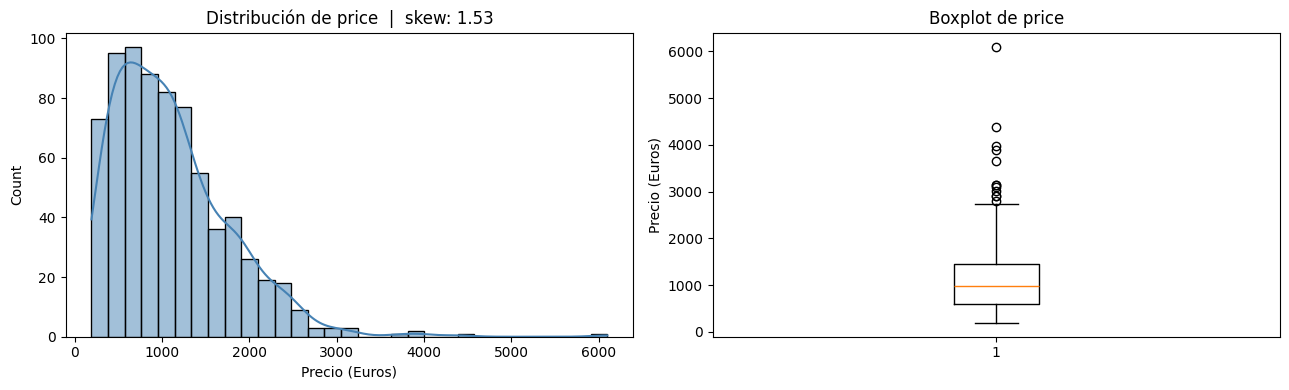

Skewness: 1.53
Rango: 192 — 6099
Media: 1104  |  Mediana: 985


In [10]:
# Visualizamos nuestra TARGET

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(y_train, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Distribución de price  |  skew: {y_train.skew():.2f}")
axes[0].set_xlabel("Precio (Euros)")

axes[1].boxplot(y_train)
axes[1].set_title("Boxplot de price")
axes[1].set_ylabel("Precio (Euros)")

plt.tight_layout()
plt.show()

print(f"Skewness: {y_train.skew():.2f}")
print(f"Rango: {y_train.min():.0f} — {y_train.max():.0f}")
print(f"Media: {y_train.mean():.0f}  |  Mediana: {y_train.median():.0f}")

In [11]:
features_num = [
    "Inches", 
    "Ram", 
    "Weight", 
    "Memory_Storage", 
    "Cpu_Frequency"
    ]

In [12]:
features_cat = [
    'Company',
    'TypeName',
    'OpSys',
    'ResolutionCategory',
    'Memory_Type',
    'Cpu_Brand',
    'Cpu_Family',
    'Gpu_Marca',
    'Gpu_Familia',
    'Touchscreen',
    'Memory_Dual',
    'Cpu_Generation'
]

In [23]:
from scipy.stats import f_oneway
import pandas as pd

def anova_categoricas(X, y, features_cat):
    """
    Calcula ANOVA para features categóricas con target numérico.
    Devuelve p-value y eta_squared (importancia / varianza explicada).
    """

    resultados = []

    for col in features_cat:
        categorias = X[col].dropna().unique()

        # grupos del target según categoría
        grupos = [y[X[col] == cat].dropna() for cat in categorias]

        # descartar grupos vacíos o de tamaño 1
        grupos = [g for g in grupos if len(g) > 1]
        if len(grupos) < 2:
            continue

        # ANOVA clásico
        f_stat, p_value = f_oneway(*grupos)

        # ANOVA inverso: eta squared
        ss_between = sum([len(g) * (g.mean() - y.mean())**2 for g in grupos])
        ss_total = sum((y - y.mean())**2)
        eta_sq = ss_between / ss_total

        resultados.append({
            'feature': col,
            'p_value': p_value,
            'eta_squared': eta_sq
        })

    df_res = pd.DataFrame(resultados)
    return df_res.sort_values('eta_squared', ascending=False)

In [26]:
anova_resultados = anova_categoricas(df_train, y_train, features_cat)
anova_resultados


,feature,p_value,eta_squared
1,TypeName,3.600265e-83,0.420282
3,ResolutionCategory,4.838946e-68,0.352487
4,Memory_Type,7.450093e-52,0.291371
8,Gpu_Familia,3.642576e-42,0.279966
11,Cpu_Generation,9.624742e-35,0.212727
6,Cpu_Family,1.411543e-32,0.209953
0,Company,8.220108e-18,0.149616
7,Gpu_Marca,3.091170e-20,0.116404
10,Memory_Dual,1.653338e-19,0.106259
2,OpSys,2.704766e-13,0.096818


In [27]:
# todos los valores del pvalue son < 0.05, y una varianza < 0.5, por lo tanto seleccionamos todas las features cat
features_cat_selec = features_cat

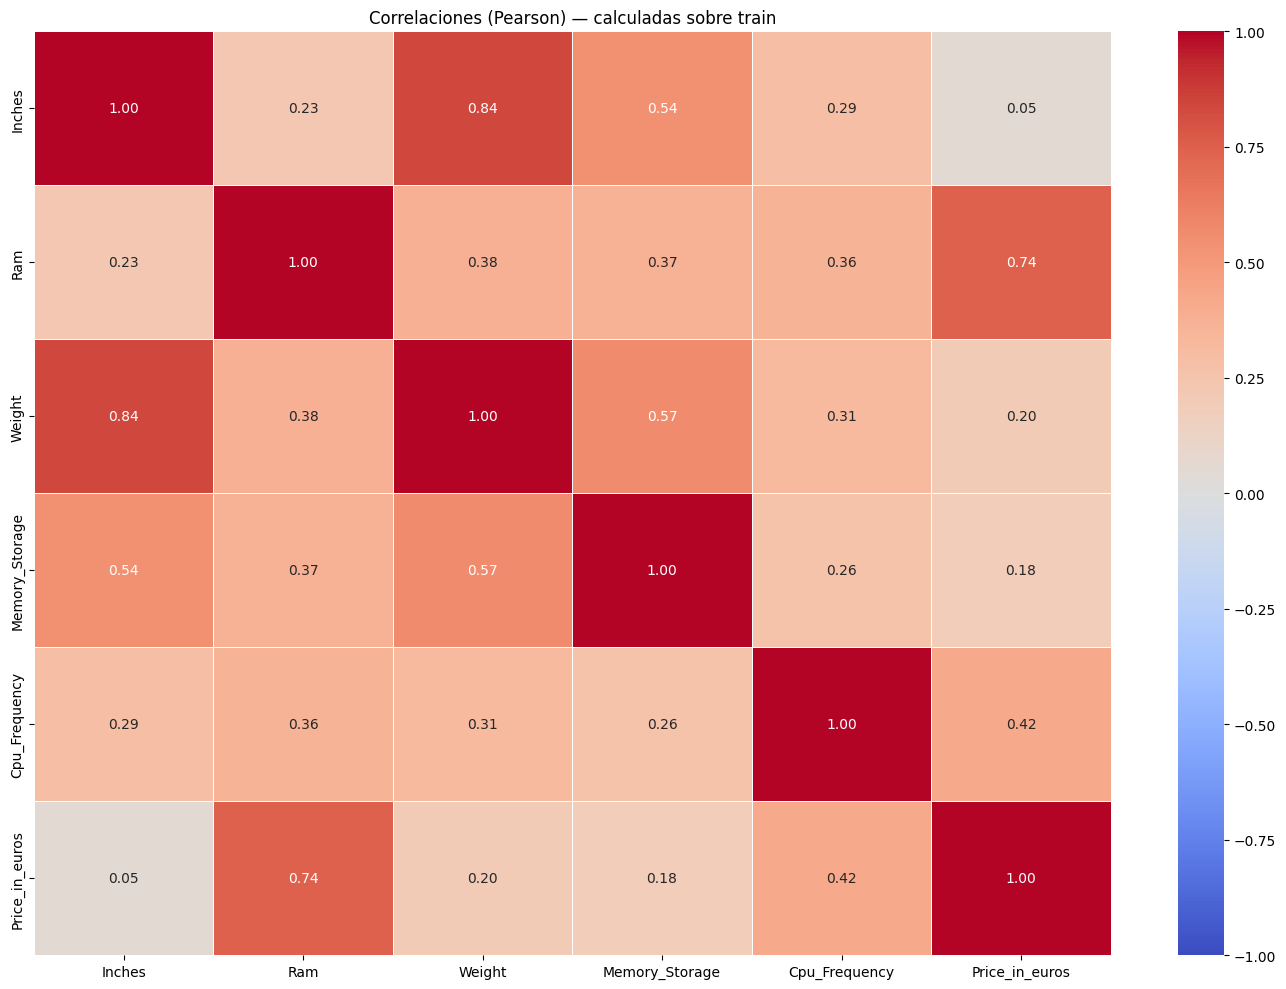


Correlación con price (ordenada):
Ram               0.744269
Cpu_Frequency     0.421229
Weight            0.202341
Memory_Storage    0.184111
Inches            0.051334


In [28]:
# Construir df con features_num + target
df_train = X_train[features_num].copy()
df_train['Price_in_euros'] = y_train.values

# Matriz de correlación
corr = df_train.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1,
            cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlaciones (Pearson) — calculadas sobre train')
plt.tight_layout()
plt.show()

# Top features por correlación con price
print("\nCorrelación con price (ordenada):")
print(
    corr['Price_in_euros']
    .drop('Price_in_euros')
    .sort_values(key=abs, ascending=False)
    .to_string()
)

In [29]:
features_num_selec = [
    'Ram',
    'Cpu_Frequency',
    ]

In [30]:
# Unimos las features seleccionadas
features_final = features_cat_selec + features_num_selec

# Creamos X_train_selec con solo esas columnas
X_train_selec = X_train[features_final]
X_test_selec = X_test[features_final]


In [31]:
describe_df(X_train_selec)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
Company,str,0.0,17,2.33
TypeName,str,0.0,6,0.82
OpSys,str,0.0,9,1.23
ResolutionCategory,str,0.0,4,0.55
Memory_Type,str,0.0,7,0.96
Cpu_Brand,str,0.0,2,0.27
Cpu_Family,str,0.0,13,1.78
Gpu_Marca,str,0.0,3,0.41
Gpu_Familia,str,0.0,21,2.88
Touchscreen,int64,0.0,2,0.27


In [32]:
# ── Encoding binario manual
binary_maps = {
    'Cpu_Brand':      {'Intel': 1, 'AMD': 0},
}

for col, mapping in binary_maps.items():
    X_train_selec[col] = X_train_selec[col].map(mapping)
    X_test_selec[col]  = X_test_selec[col].map(mapping)

In [33]:
from sklearn.preprocessing import OneHotEncoder

# 1. Quitar Cpu_Brand (map) de las categóricas para OHE
cat_cols_ohe = [col for col in features_cat_selec if col != "Cpu_Brand"]

# 2. OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

ohe_train = encoder.fit_transform(X_train_selec[cat_cols_ohe])
ohe_test  = encoder.transform(X_test_selec[cat_cols_ohe])

ohe_names = encoder.get_feature_names_out(cat_cols_ohe)

# 3. Reemplazar columnas originales por las codificadas
X_train_selec = pd.concat([
    X_train_selec.drop(columns=cat_cols_ohe),
    pd.DataFrame(ohe_train, columns=ohe_names, index=X_train_selec.index)
], axis=1)

X_test_selec = pd.concat([
    X_test_selec.drop(columns=cat_cols_ohe),
    pd.DataFrame(ohe_test, columns=ohe_names, index=X_test_selec.index)
], axis=1)

print(f"Shape tras encoding: X_train {X_train_selec.shape}  |  X_test {X_test_selec.shape}")
print(f"Total features: {X_train_selec.shape[1]}")

Shape tras encoding: X_train (729, 83)  |  X_test (183, 83)
Total features: 83


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 4, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


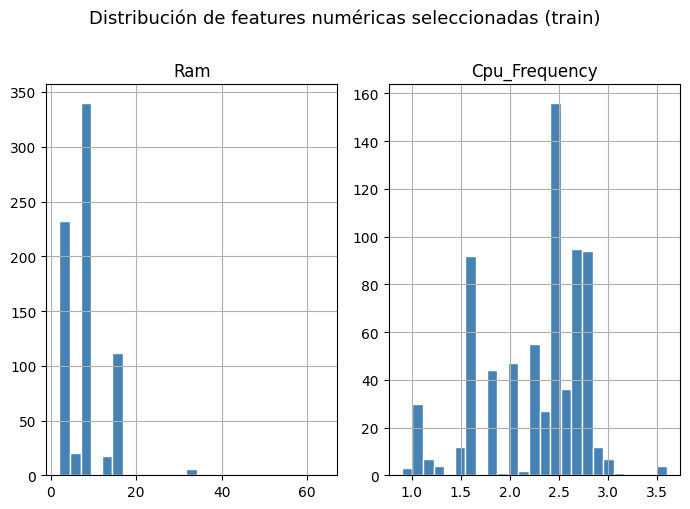


Skewness de features_num_selec:
Ram              3.189739
Cpu_Frequency   -0.718543


In [34]:
X_train_selec[features_num_selec].hist(
    figsize=(7, 5), bins=25, edgecolor='white', color='steelblue'
)
plt.suptitle('Distribución de features numéricas seleccionadas (train)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("\nSkewness de features_num_selec:")
print(X_train_selec[features_num_selec].skew().sort_values(key=abs, ascending=False).to_string())


In [35]:
X_train_scaled = X_train_selec.copy()
X_test_scaled  = X_test_selec.copy()

# Transformaciones
X_train_scaled['Ram'] = np.log1p(X_train_scaled['Ram'])
X_test_scaled['Ram']  = np.log1p(X_test_scaled['Ram'])

X_train_scaled['Cpu_Frequency'] = np.cbrt(X_train_scaled['Cpu_Frequency'])
X_test_scaled['Cpu_Frequency']  = np.cbrt(X_test_scaled['Cpu_Frequency'])

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled[features_num_selec] = scaler.fit_transform(X_train[features_num_selec])
X_test_scaled[features_num_selec]  = scaler.transform(X_test[features_num_selec])


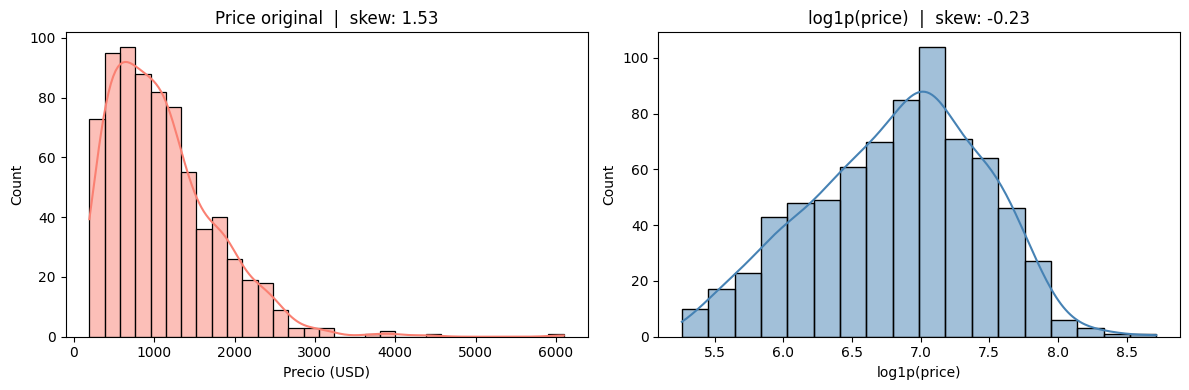

In [37]:
# Aplicamos la transformación logarítmica a la target
# Visualizar antes y después

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_train, kde=True, ax=axes[0], color='salmon')
axes[0].set_title(f'Price original  |  skew: {y_train.skew():.2f}')
axes[0].set_xlabel('Precio (USD)')

y_train_log = np.log1p(y_train)
sns.histplot(y_train_log, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title(f'log1p(price)  |  skew: {y_train_log.skew():.2f}')
axes[1].set_xlabel('log1p(price)')

plt.tight_layout()
plt.show()


In [42]:
# Aplicar la transformación
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f"Skew antes:  {y_train.skew():.3f}")
print(f"Skew después: {y_train_log.skew():.3f}")

Skew antes:  1.533
Skew después: -0.234


In [43]:
# Detectar outliers con IQR
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_price = y_train[(y_train < lower) | (y_train > upper)]

print(f"Límites IQR: [{lower:.0f}, {upper:.0f}]")
print(f"Outliers detectados: {len(outliers_price)}\n")

# Mostrar productos fuera del rango
df_outliers = X_train.loc[outliers_price.index].copy()
df_outliers['target'] = y_train
print(df_outliers)

Límites IQR: [-695, 2753]
Outliers detectados: 12

     laptop_ID Company            Product     TypeName  Inches  Ram  \
25        1118      HP           ZBook 17  Workstation    17.3    8   
131        731    Dell       Alienware 17       Gaming    17.3   32   
578        243    Asus  ROG G703VI-E5062T       Gaming    17.3   32   
393        924      HP    Elitebook Folio    Ultrabook    12.5    8   
221        431    Dell       Alienware 17       Gaming    17.3   16   
792        982    Dell       Alienware 17       Gaming    17.3   32   
423       1081    Asus         ROG G701VO       Gaming    17.3   64   
261        537    Dell       Alienware 17       Gaming    17.3   16   
658        667    Dell       Alienware 17       Gaming    17.3   32   
47         787   Razer          Blade Pro       Gaming    14.0   16   
52         200   Razer          Blade Pro       Gaming    17.3   32   
769        758      HP           Zbook 17  Workstation    17.3   16   

          OpSys  Weight  

## 4. Modelado

25     7.972466
84     7.131107
10     7.580649
342    6.939244
890    7.242082
         ...   
106    5.966147
270    6.309918
860    7.528332
435    5.726848
102    7.572503
Name: Price_in_euros, Length: 729, dtype: float64

### 4.1 Entrenamiento

In [ ]:
# Tu código aquí


### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [ ]:
# Tu código aquí


### 4.3 Optimización (up to you 🫰🏻)

In [ ]:
# Tu código aquí


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [ ]:
# Tu código aquí


---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [ ]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [ ]:
# Tu código aquí


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [ ]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

### 8.2 Crea tu submission

In [ ]:
predictions_submit = model_final.predict(X_pred)

submission = pd.DataFrame({
    'laptop_ID': sample['laptop_ID'],
    'Price_in_euros': predictions_submit
})

submission.head()


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [ ]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [ ]:
checker(submission, sample)